In [2]:
import pandas as pd
from scipy.stats import spearmanr
import joblib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import properscoring as ps

import config
from nn_utils.dataset import load_dataset
from utils.plotting import generate_animation

C:\Users\yvjennig\Anaconda3\envs\time_imputation\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
# model_name = "mastnet"
# exp_id = "exp252"
# base_dir = Path(f"D:/phd/output/tuning/mastnet/architecture_ablation") / exp_id

# model_name = "mlp"
# exp_id = ""
# base_dir = Path(f"output/testing/") / model_name / exp_id

# model_name = "mastnet"
# exp_id = "exp73"
# base_dir = Path(f"output/testing/") / model_name / exp_id

model_name = "mastnet"
exp_id = ""
base_dir = Path(f"output/testing/") / model_name

# Load scaled input data/groud truth
# df_true = pd.read_csv(base_dir / f"model{model_name}_y_true.csv")
df_true = pd.read_csv(base_dir / f"model{model_name}_y_true.csv")
y_true = df_true[config.parameters].to_numpy()

# Load inferences
all_preds = np.load(base_dir / f"model{model_name}_splitfinal_trial0_all_preds.npy")
all_vars = np.load(base_dir / f"model{model_name}_splitfinal_trial0_all_vars.npy")

n_inferences, n_samples, n_features = all_preds.shape

In [4]:
# Epistemic variance from MC dropout
epistemic_var = np.var(all_preds, axis=0)
epistemic_std = np.sqrt(epistemic_var)

# Aleatoric variance from heteroscedastic head
aleatoric_var = np.mean(np.exp(all_vars), axis=0)  # Model predicts log variance
aleatoric_std = np.sqrt(aleatoric_var)

# Predictive mean
y_pred_mean = np.mean(all_preds, axis=0)

# Total variance
total_var = epistemic_var + aleatoric_var
total_std = np.sqrt(total_var)

# Uncertainty-missingness correlation

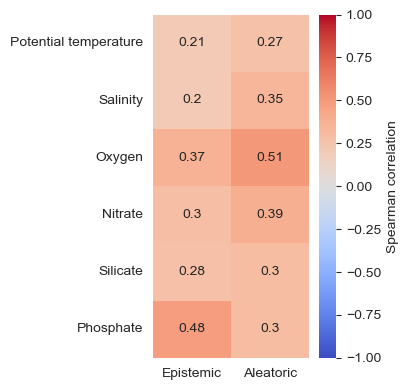

In [33]:
# Uncertainty-missingness correlation
df = df_true.copy()
df["miss"] = df[config.parameters].isna().sum(axis=1) / len(config.parameters)

corrs_epi = []
corrs_alea = []

for i, feat in enumerate(config.parameters):
    sc_epi = spearmanr(epistemic_std[:, i], df["miss"].values).statistic
    sc_alea = spearmanr(aleatoric_std[:, i], df["miss"].values).statistic

    corrs_epi.append(sc_epi)
    corrs_alea.append(sc_alea)

corrs = pd.DataFrame({
    "Feature": [config.parameter_name_map[f] for f in config.parameters],
    "Epistemic": corrs_epi,
    "Aleatoric": corrs_alea
})
corrs = corrs.set_index("Feature")

plt.figure(figsize=(4, 4))
sns.heatmap(corrs, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, cbar_kws={"label": "Spearman correlation"})
plt.ylabel("")
plt.tight_layout()
plt.savefig("output/plots/uncertainty/uncertainty_missingness_correlation.png", bbox_inches="tight", dpi=300)
plt.show()

In [29]:
# Aleatoric -> Are noisy regions poorly sampled?
# Epistemic -> Does lack of knowledge/data increase uncertainty?

# Oxygen: Missing regions coincide with complex dynamics, system is noisy here
# Phosphate: Model becomes uncertaint where data is sparse -> Lack of knowledge
# all positive --> unc increase in reginos of higher missingness


# Residuals
--> Is mean correct?

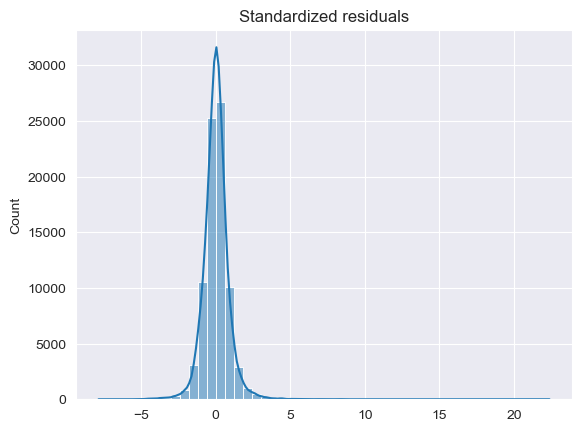

Mean z: 0.03079932994789371
Std z: 0.8709732713194803


In [4]:
# Compute overall residuals
z = (y_true - y_pred_mean) / total_std

# Compute per-feature z
results = []
for d in range(y_true.shape[1]):
    y = y_true[:, d]
    mu = y_pred_mean[:, d]
    sigma = total_std[:, d]

    valid = ~np.isnan(y)
    z = (y[valid] - mu[valid]) / sigma[valid]

    results.append({
        "feature": d,
        "z_mean": np.nanmean(z),
        "z_std": np.nanstd(z),
        "n_obs": np.sum(valid)
    })
df_z = pd.DataFrame(results)

# Plot
sns.histplot(z.flatten(), bins=50, kde=True)
plt.title("Standardized residuals")
plt.show()

print("Mean z:", np.nanmean(z))
print("Std z:", np.nanstd(z))

In [5]:
df_z

,feature,z_mean,z_std,n_obs
0,0,0.246529,0.868516,143933
1,1,-0.089531,0.799842,159907
2,2,-0.030576,1.075123,131326
3,3,0.293586,0.890306,55349
4,4,-0.201466,0.785106,69043
5,5,0.030799,0.870973,81744


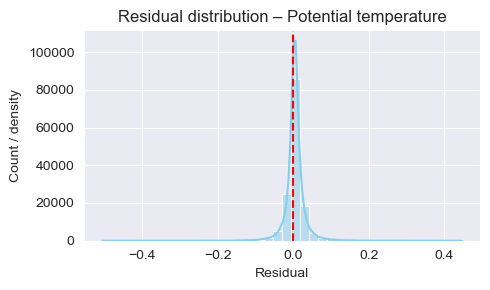

P_TEMPERATURE: mean=0.0043, std=0.0269, skew=-0.160, kurt=23.818


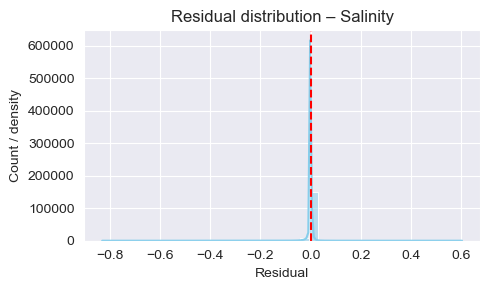

P_SALINITY: mean=-0.0006, std=0.0139, skew=-10.401, kurt=649.089


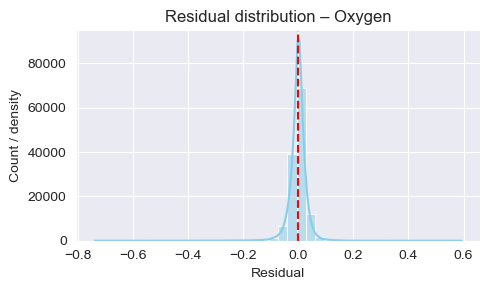

P_OXYGEN: mean=-0.0016, std=0.0332, skew=-2.209, kurt=33.850


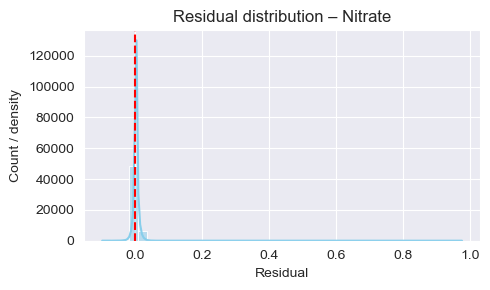

P_NITRATE: mean=0.0020, std=0.0127, skew=35.553, kurt=2301.033


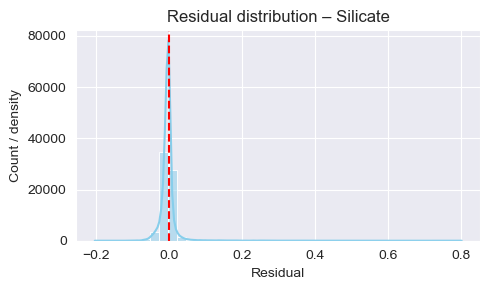

P_SILICATE: mean=-0.0027, std=0.0287, skew=9.008, kurt=138.981


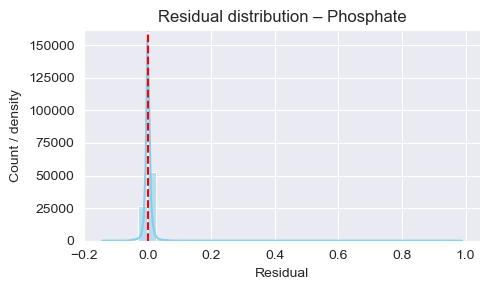

P_PHOSPHATE: mean=0.0005, std=0.0130, skew=15.186, kurt=878.368


In [6]:
# Residuals per feature to help decide on the loss
# y_pred_mean: (N, D)
# y_true: (N, D)
n_features = y_true.shape[1]

for j, name in enumerate(config.parameters):
    res = y_true[:, j] - y_pred_mean[:, j]
    valid = np.isfinite(res)
    res = res[valid]

    plt.figure(figsize=(5,3))
    sns.histplot(res, bins=40, kde=True, color="skyblue")
    plt.axvline(0, color="r", linestyle="--")
    plt.title(f"Residual distribution – {config.parameter_name_map.get(name, name)}")
    plt.xlabel("Residual")
    plt.ylabel("Count / density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"{name}: mean={res.mean():.4f}, std={res.std():.4f}, skew={pd.Series(res).skew():.3f}, kurt={pd.Series(res).kurt():.3f}")

# Diagnostics

In [14]:
corr_epistemic = []
corr_aleatoric = []
corr_total = []

for i in range(n_features):
    # Squared error
    se = (y_true[:, i] - y_pred_mean[:, i])**2

    # Uncertainties of current feature
    v_epi = epistemic_std[:, i]
    v_alea = aleatoric_std[:, i]
    v_total = total_std[:, i]

    # Filter for not-nan values
    valid = np.isfinite(se)
    valid_epi = valid & np.isfinite(v_epi) & (v_epi > 0)
    valid_alea = valid & np.isfinite(v_alea) & (v_alea > 0)
    valid_total = valid & np.isfinite(v_total) & (v_total > 0)

    # Correlations
    corr_epi, _ = spearmanr(se[valid_epi], v_epi[valid_epi])
    corr_alea, _ = spearmanr(se[valid_alea], v_alea[valid_alea])
    corr_tot, _ = spearmanr(se[valid_total], v_total[valid_total])

    corr_epistemic.append(corr_epi)
    corr_aleatoric.append(corr_alea)
    corr_total.append(corr_tot)

corrs = pd.DataFrame({"Feature": config.parameters, "Epistemic": corr_epistemic, "Aleatoric": corr_aleatoric, "Total": corr_total})
corrs

Feature | corr(epistemic) | corr(aleatoric) | corr(total)


,Feature,Epistemic,Aleatoric,Total
0,P_TEMPERATURE,0.459910,0.518514,0.519717
1,P_SALINITY,0.560401,0.561858,0.565317
2,P_OXYGEN,0.310019,0.396759,0.400366
3,P_NITRATE,0.342917,0.419638,0.423906
4,P_SILICATE,0.456760,0.598159,0.599015
5,P_PHOSPHATE,0.374326,0.442729,0.445143


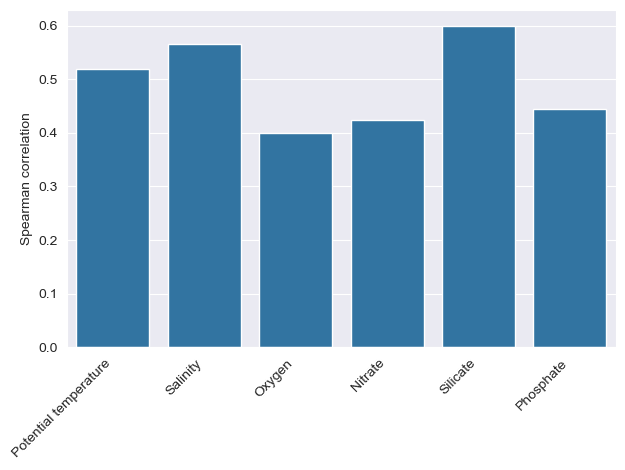

In [8]:
temp = corrs.copy()
temp["Feature"] = temp["Feature"].map(config.parameter_name_map)
sns.barplot(temp, x="Feature", y="Total")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Spearman correlation") # Correlation uncertainty ~ squared error")
plt.tight_layout()
plt.savefig("output/plots/uncertainty/corr_total.png")
plt.show()

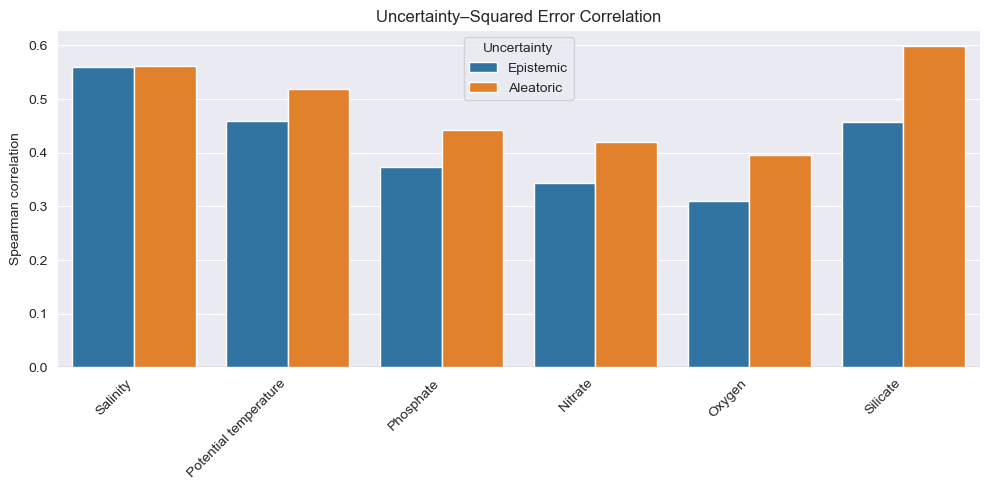

In [15]:
# Error–uncertainty correlations per feature
# -> Is the uncertainty useful for ranking difficult points?

# Sorting
temp = corrs.copy()
temp["delta"] = temp["Aleatoric"] - temp["Epistemic"]
temp = temp.sort_values("delta")

# Melting
df_melt = temp.melt(id_vars="Feature", value_vars=["Epistemic", "Aleatoric"], var_name="Uncertainty", value_name="Spearman")
df_melt["Feature"] = df_melt["Feature"].map(config.parameter_name_map)

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(data=df_melt, x="Feature", y="Spearman", hue="Uncertainty")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Spearman correlation")
plt.title("Uncertainty–Squared Error Correlation")
plt.xlabel("")
plt.tight_layout()

# Save
#file_name = base_dir / f"{model_name+exp_id.lstrip('/')}_uncertainty_se_correlation.png"
#plt.savefig(file_name)
plt.savefig(f"output/plots/uncertainty/uncertainty_rmse_correlation_{model_name}_{exp_id.lstrip('/')}.png")
plt.show()

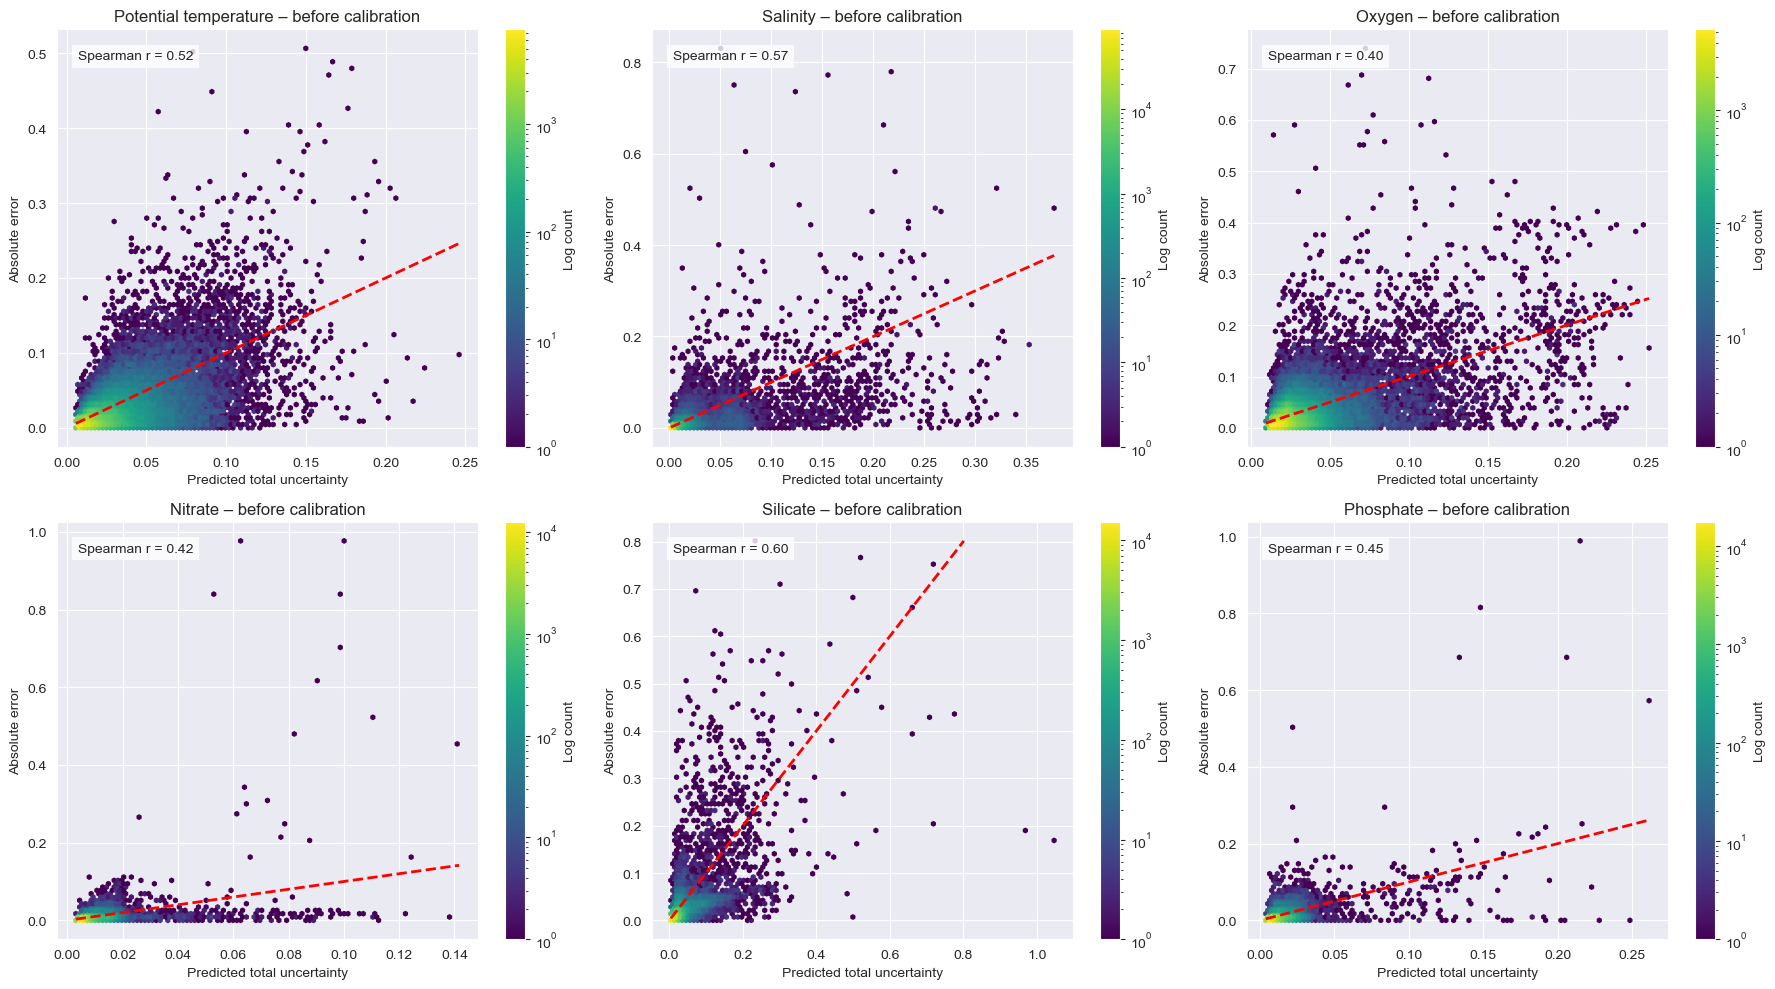

In [16]:
# Absolute error vs predicted uncertainty (usefulness plot)
abs_err = np.abs(y_pred_mean - y_true)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for j, name in enumerate(config.parameters):
    ax = axes[j]

    x = total_std[:, j]
    y = abs_err[:, j]

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y >= 0)
    x = x[valid]
    y = y[valid]

    # Main plot and color bar
    hb = ax.hexbin(x, y, bins="log", cmap="viridis")
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label(label="Log count")

    # Ideal diagonal |e| = sigma
    xmin = max(np.min(x), np.min(y))
    xmax = min(np.max(x), np.max(y))
    xx = np.logspace(np.log10(xmin), np.log10(xmax), 200)
    ax.plot(xx, xx, "r--", linewidth=2, label=r"$|e|=\sigma$")

    # Spearman correlation
    spearman_r = spearmanr(x, y).statistic #[0, 1]
    ax.text(
        0.05, 0.95,
        s=f"Spearman r = {spearman_r:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_xlabel("Predicted total uncertainty")
    ax.set_ylabel("Absolute error")
    ax.set_title(f"{config.parameter_name_map[name]} – before calibration")
    ax.grid(True)

plt.tight_layout()
plt.show()

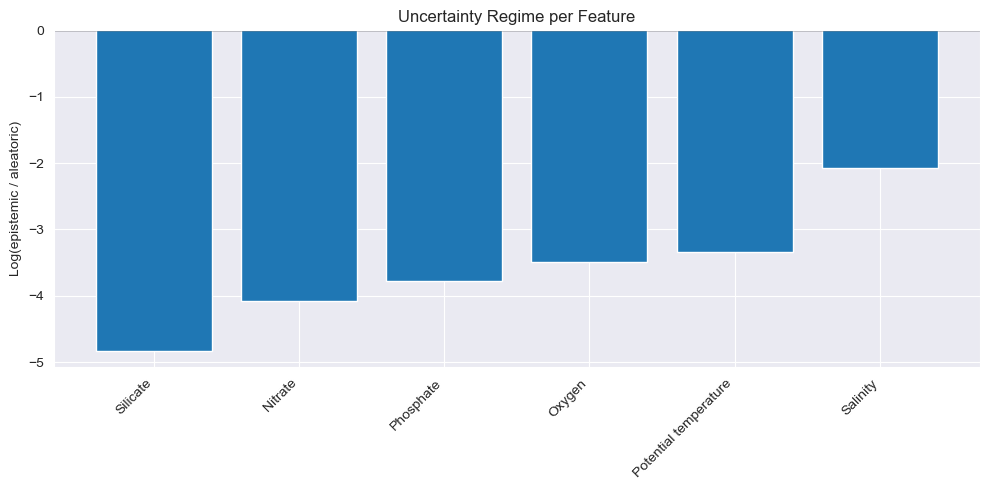

In [36]:
# Uncertainty regime
# Compute mean variances over samples
epi_mean  = np.mean(epistemic_var, axis=0)
alea_mean = np.mean(aleatoric_var, axis=0)

# Regime score (log dominance)
regime_score = np.log(epi_mean / alea_mean)

# Build df
df_reg = pd.DataFrame({"Feature": config.parameters, "RegimeScore": regime_score})
df_reg["Feature"] = df_reg["Feature"].map(config.parameter_name_map)

# Sort
df_reg = df_reg.sort_values("RegimeScore")

# Plot
plt.figure(figsize=(10, 5))

# blue = "#1f77b4"
# red = "#C44E52"
#colors = [red if v > 0 else blue for v in df_reg["RegimeScore"]]

plt.bar(df_reg["Feature"], df_reg["RegimeScore"])  #, color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Log(epistemic / aleatoric)")
plt.title("Uncertainty Regime per Feature")

plt.tight_layout()
plt.savefig("output/plots/uncertainty/uncertainty_regimes.png")
plt.show()

In [42]:
# Dominance factors
1/np.exp(df_reg["RegimeScore"])

4    126.108124
3     59.397224
5     43.783253
2     32.593014
0     28.091429
1      7.953560
Name: RegimeScore, dtype: float32

# Reliability
--> Do predicted uncertainties match empirical frequencies?
--> Is uncertainty calibrated?

In [ ]:
levels = np.linspace(0.01, 0.99, 20)

# Compute curves
all_curves = []
for d in range(y_true.shape[1]):

    y = y_true[:, d]
    mu = y_pred_mean[:, d]
    sigma = total_std[:, d]

    curve = []

    for l in levels:
        z = norm.ppf(0.5 + l/2)
        lower = mu - z * sigma
        upper = mu + z * sigma

        valid = ~np.isnan(y)
        cov = np.mean((y[valid] >= lower[valid]) & (y[valid] <= upper[valid]))
        curve.append(cov)

    all_curves.append(curve)

all_curves = np.array(all_curves)

mean_curve = np.nanmean(all_curves, axis=0)
std_curve = np.nanstd(all_curves, axis=0)

miscal_areas = [ np.trapezoid(np.abs(curve - levels), levels) for curve in all_curves]
miscal_area = np.mean(miscal_areas)
miscal_area_std = np.std(miscal_areas)
ideal = levels

# Plot
plt.figure(figsize=(6,5))
plt.plot(levels, mean_curve, label="Model", linewidth=2)  # Model curve
plt.fill_between(levels, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)  # Parameter variability band
plt.plot(levels, ideal, "k--", label="Ideal")  # Ideal
plt.fill_between(levels, mean_curve, ideal, color="red", alpha=0.2, label="Miscalibration area")  # Miscalibration area
plt.text(0.95, 0.05, f"Miscalibration area = {miscal_area:.2f} +- {miscal_area_std:.2f}", transform=plt.gca().transAxes, bbox=dict(facecolor="white", alpha=0.7), ha="right", va="bottom")  # Miscalibration value

plt.xlabel("Nominal coverage")
plt.xlabel("Predicted proportion in interval")
plt.ylabel("Empirical coverage")
plt.ylabel("Observed proportion in interval")
plt.title("Calibration")
plt.legend()
# plt.grid()
plt.tight_layout()

# file_name = base_dir / f"{model_name+exp_id.lstrip('/')}_uncertainty_calibration.png"
# plt.savefig(file_name)
plt.savefig(f"output/plots/uncertainty/{model_name+exp_id.lstrip('/')}_uncertainty_calibration.png")
plt.show()

In [ ]:
for i, param in enumerate(config.parameter_name_map.values()):
    plt.plot(levels, all_curves[i], label=param)

# Miscalibration area per feature
miscal_areas = [np.trapezoid(np.abs(curve - levels), levels) for curve in all_curves]
mean_miscal = np.mean(miscal_areas)
std_miscal = np.std(miscal_areas)

plt.plot(levels, levels, "k--", label="Ideal")
plt.text(
    0.95,
    0.05,
    f"Miscalibration area\n"
    f"{mean_miscal:.3f} ± {std_miscal:.3f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        alpha=0.7,
        #edgecolor="gray"
    )
)
plt.legend()
plt.xlabel("Predicted proportion in interval")
plt.ylabel("Observed proportion in interval")
plt.title("Calibration per feature")
plt.tight_layout()

# file_name = base_dir / f"{model_name+exp_id.lstrip('/')}_uncertainty_calibration_per_feature.png"
# plt.savefig(file_name)
plt.savefig(f"output/plots/uncertainty/{model_name+exp_id.lstrip('/')}_uncertainty_calibration_per_feature.png")
plt.show()

In [ ]:
print(f"mean_curve: {mean_curve}\n\nstd_curve: {std_curve}\n\nmiscal_area: {miscal_area}\n\nmiscal_area_std: {miscal_area_std}")

# CRPS
--> Is forecast good?

In [ ]:
crps = []
for d in range(y_true.shape[1]):
    ens = all_preds[:, :, d].T  # (samples, ensemble)
    obs = y_true[:, d]
    crps.append(np.nanmean(ps.crps_ensemble(obs, ens)))

print("CRPS per feature:", crps)

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(crps)
plt.xticks(ticks=range(len(config.parameters)), labels=config.parameter_name_map.values())
plt.ylabel("CRPS")
plt.tight_layout()

# file_name = base_dir / f"{model_name+exp_id.lstrip('/')}_uncertainty_crps.png"
# plt.savefig(file_name)
plt.savefig(f"output/plots/uncertainty/{model_name+exp_id.lstrip('/')}_uncertainty_crps.png")
plt.show()

# Animations

In [43]:
# Animate uncertainties
df = load_dataset()
scaler_dict = joblib.load(base_dir / f"scalers.joblib")

df_unc = pd.DataFrame(total_std, columns=config.parameters)
df_unc[config.coordinates] = df[config.coordinates]

df_ale = pd.DataFrame(aleatoric_std, columns=config.parameters)
df_ale[config.coordinates] = df[config.coordinates]

df_epi = pd.DataFrame(epistemic_std, columns=config.parameters)
df_epi[config.coordinates] = df[config.coordinates]

for param in config.parameters:
    # Reconstruction animations
    generate_animation(df_unc, scaler_dict=scaler_dict, parameter=param, save_as=f"output/plots/uncertainty/model{model_name+exp_id.lstrip('/')}_{param}_uncertainty.mp4")
    # generate_animation(df_ale, scaler_dict=scaler_dict, parameter=param, save_as=f"output/plots/uncertainty/model{model_name+exp_id.lstrip('/')}_{param}_aleatoric_uncertainty.mp4")
    # generate_animation(df_epi, scaler_dict=scaler_dict, parameter=param, save_as=f"output/plots/uncertainty/model{model_name+exp_id.lstrip('/')}_{param}_epistemic_uncertainty.mp4")


Animation saved as output/plots/uncertainty/modelmastnet_P_TEMPERATURE_uncertainty.mp4
Animation saved as output/plots/uncertainty/modelmastnet_P_SALINITY_uncertainty.mp4
Animation saved as output/plots/uncertainty/modelmastnet_P_OXYGEN_uncertainty.mp4
Animation saved as output/plots/uncertainty/modelmastnet_P_NITRATE_uncertainty.mp4
Animation saved as output/plots/uncertainty/modelmastnet_P_SILICATE_uncertainty.mp4
Animation saved as output/plots/uncertainty/modelmastnet_P_PHOSPHATE_uncertainty.mp4
